# POLITECNICO DI MILANO 1863

## Course: Embedded and Edge Artificial Intelligence  
## Professor: Prof. Manuel Roveri  
## Academic Year: 2025/2026  

---
**Topic:** Lab — Designing a CNN for Image Classification  
**Objective:** Design, train and evaluate a Convolutional Neural Network (CNN) for image classification on CIFAR-10.  
Students will experiment with different numbers of convolutional layers and filter counts, and observe the effect on accuracy and model size (number of parameters).

---

## 1. Environment Setup

We import the necessary libraries for data loading, network definition, training, and visualization.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import io

# Set seed for reproducibility
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Dataset: CIFAR-10

**CIFAR-10** is a standard benchmark dataset for image classification.  
It contains **60,000 colour images** (32×32 pixels, 3 channels RGB) divided into **10 classes**:

> airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

- **Training set:** 50,000 images → split into 40,000 train / 10,000 validation  
- **Test set:** 10,000 images (fixed — do not modify this cell)

Pixel values are normalised to the range [0, 1] by dividing by 255.

In [2]:
# ─── FIXED — do not modify this cell ──────────────────────────────────────
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CLASS_NAMES)
IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS = 32, 32, 3

# Load dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalise pixel values to [0, 1]
x_train_full = x_train_full.astype(np.float32) / 255.0
x_test       = x_test.astype(np.float32)       / 255.0

# Flatten class labels
y_train_full = y_train_full.flatten()
y_test       = y_test.flatten()

# Split: 40,000 train / 10,000 validation
x_train, x_val = x_train_full[:40000], x_train_full[40000:]
y_train, y_val = y_train_full[:40000], y_train_full[40000:]

print(f"Training   set: {x_train.shape}")
print(f"Validation set: {x_val.shape}")
print(f"Test       set: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training   set: (40000, 32, 32, 3)
Validation set: (10000, 32, 32, 3)
Test       set: (10000, 32, 32, 3)


## 3. Data Visualisation

Before designing the model, it is always good practice to inspect a few samples from the dataset to understand what the network will learn to classify.

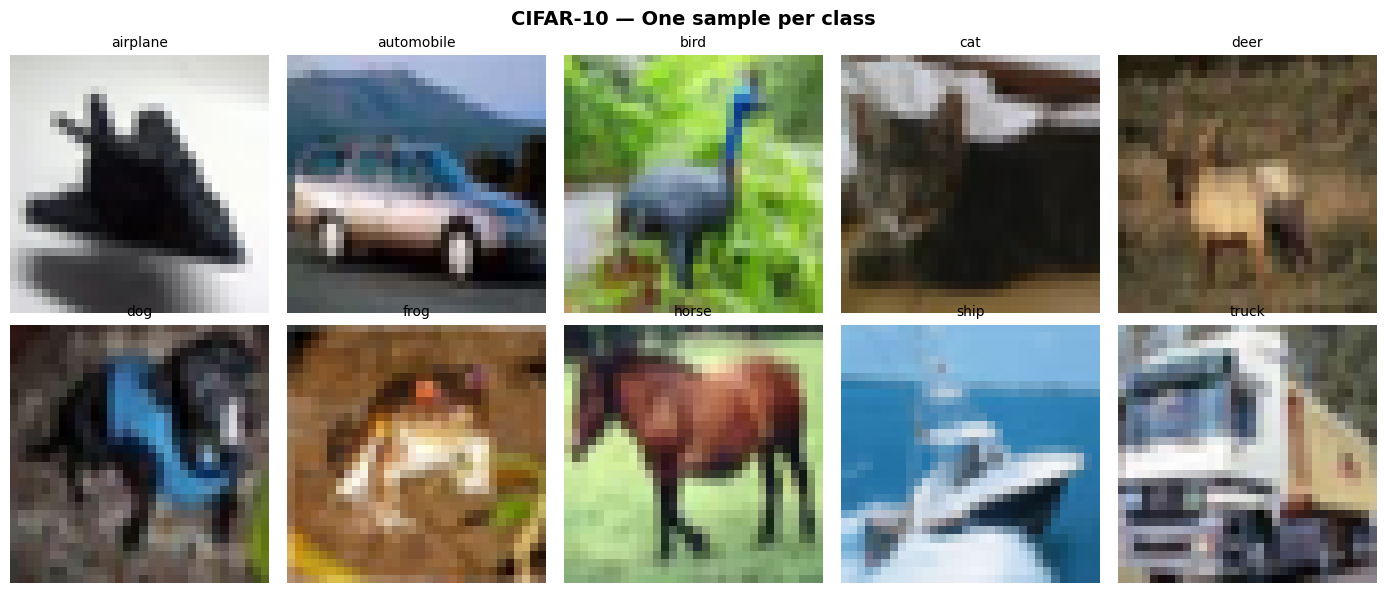

In [3]:
# Show one random sample per class from the training set
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CIFAR-10 — One sample per class', fontsize=14, fontweight='bold')

for cls_idx, ax in enumerate(axes.flat):
    # Pick the first occurrence of this class in the training set
    sample_idx = np.where(y_train == cls_idx)[0][0]
    ax.imshow(x_train[sample_idx])
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. ⚙️  Student Configuration — CNN Architecture

**This is the cell you should modify.**

A CNN for image classification is composed of a *feature extractor* (stack of convolutional blocks) followed by a *classifier* (Dense layers).  
Each **convolutional block** in this lab consists of:

```
Conv2D(filters, 3×3, padding='same') → ReLU → MaxPooling2D(2×2)
```

**Parameters you can tune:**

| Parameter | Description | Suggested range |
|-----------|-------------|----------------|
| `CONV_FILTERS` | List with the number of filters for each convolutional block. The length of the list determines the number of blocks. | e.g. `[32]`, `[32, 64]`, `[32, 64, 128]` |
| `DENSE_UNITS` | Number of neurons in the fully-connected hidden layer after flattening. | 64 – 512 |
| `DROPOUT_RATE` | Fraction of activations randomly dropped during training to reduce overfitting. Set to 0 to disable. | 0.0 – 0.5 |
| `EPOCHS` | Number of full passes over the training set. | 10 – 50 |
| `BATCH_SIZE` | Number of samples processed before each weight update. | 32 – 256 |

In [4]:
# ══════════════════════════════════════════════════
#   STUDENT CONFIGURATION — modify values below
# ══════════════════════════════════════════════════

# List of filter counts, one entry per convolutional block.
# Example: [32]         → 1 convolutional block with 32 filters
#          [32, 64]     → 2 convolutional blocks: 32 then 64 filters
#          [32, 64, 128]→ 3 convolutional blocks: 32, 64, then 128 filters
CONV_FILTERS = [32, 64]          # <-- CHANGE THIS

# Number of neurons in the Dense (fully connected) hidden layer
DENSE_UNITS  = 128               # <-- CHANGE THIS

# Dropout regularisation (0.0 = disabled)
DROPOUT_RATE = 0.3               # <-- CHANGE THIS

# Training hyperparameters
EPOCHS     = 20                  # <-- CHANGE THIS
BATCH_SIZE = 64                  # <-- CHANGE THIS

# ══════════════════════════════════════════════════
print(f"Architecture: {len(CONV_FILTERS)} conv block(s), filters = {CONV_FILTERS}")
print(f"Dense layer:  {DENSE_UNITS} units  |  Dropout: {DROPOUT_RATE}")
print(f"Training:     {EPOCHS} epochs, batch size = {BATCH_SIZE}")

Architecture: 2 conv block(s), filters = [32, 64]
Dense layer:  128 units  |  Dropout: 0.3
Training:     20 epochs, batch size = 64


## 5. Model Definition

The CNN is built automatically from the configuration above.  
The architecture follows the classic pattern:

```
Input (32×32×3)
  └─► [Conv2D → ReLU → MaxPool]  ×  NUM_BLOCKS     ← feature extractor
  └─► Flatten
  └─► Dense(DENSE_UNITS) → ReLU → Dropout
  └─► Dense(10) → Softmax                          ← classifier
```

Each `MaxPooling2D(2×2)` halves the spatial resolution:  
32 → 16 → 8 → 4 (with 3 blocks). After `k` pooling layers the feature map is `32/2^k × 32/2^k`.

> **Note for edge deployment:** the number of parameters directly affects  
> the Flash memory requirement (weights) and the RAM requirement (activations).

In [5]:
def build_cnn(conv_filters, dense_units, dropout_rate,
              img_h=IMG_HEIGHT, img_w=IMG_WIDTH, img_c=IMG_CHANNELS,
              num_classes=NUM_CLASSES):
    """
    Builds a configurable CNN for image classification.

    Args:
        conv_filters  : list[int] — number of filters for each Conv block.
        dense_units   : int       — neurons in the FC hidden layer.
        dropout_rate  : float     — dropout fraction (0 = no dropout).
        img_h, img_w  : int       — input image spatial dimensions.
        img_c         : int       — number of input channels.
        num_classes   : int       — number of output classes.

    Returns:
        A compiled tf.keras.Model.
    """
    inputs = Input(shape=(img_h, img_w, img_c))
    x = inputs

    # ── Feature Extractor: stack of Conv blocks ──────────────────────────
    for block_idx, n_filters in enumerate(conv_filters):
        x = layers.Conv2D(
            filters=n_filters,
            kernel_size=(3, 3),
            padding='same',
            activation='relu',
            name=f'conv_block{block_idx+1}'
        )(x)
        x = layers.MaxPooling2D(pool_size=(2, 2),
                                name=f'pool_block{block_idx+1}')(x)

    # ── Classifier: Dense layers ─────────────────────────────────────────
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(dense_units, activation='relu', name='fc1')(x)

    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate, name='dropout')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Build the model using the student configuration
model = build_cnn(
    conv_filters=CONV_FILTERS,
    dense_units=DENSE_UNITS,
    dropout_rate=DROPOUT_RATE
)

## 6. Model Summary and Parameter Analysis

The `model.summary()` function reports:

- **Output Shape** of each layer: tracks how the spatial dimensions and the channel count change through the network.
- **Param #**: number of learnable parameters (weights + biases) in each layer.
- **Total params**: total parameter count, proportional to the **Flash memory** needed on an edge device (float32 → 4 bytes/param).

> For a Conv2D layer with $F$ filters and kernel $k{\times}k$ operating on $C$ input channels:  
> $$\text{Params} = (k^2 \cdot C + 1) \cdot F$$  
> (the $+1$ accounts for the bias of each filter).

In [6]:
# Print the full model summary
model.summary()

# ── Memory estimates (float32, 4 bytes per parameter) ────────────────────
total_params      = model.count_params()
trainable_params  = sum(tf.size(w).numpy() for w in model.trainable_weights)

flash_kB = total_params * 4 / 1024          # weights stored in Flash

print("\n" + "═" * 55)
print(f"  Total parameters        : {total_params:>10,}")
print(f"  Trainable parameters    : {trainable_params:>10,}")
print(f"  Flash memory (float32)  : {flash_kB:>10.1f} KB")
print(f"  Flash memory (float32)  : {flash_kB/1024:>10.3f} MB")
print("═" * 55)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block1 (Conv2D)            │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2 (Conv2D)            │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)


═══════════════════════════════════════════════════════
  Total parameters        :    545,098
  Trainable parameters    :    545,098
  Flash memory (float32)  :     2129.3 KB
  Flash memory (float32)  :      2.079 MB
═══════════════════════════════════════════════════════


## 7. Training

We train the model using the **Adam** optimiser and **Sparse Categorical Cross-Entropy** loss.  
The validation set is used to monitor generalisation during training and detect overfitting.

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 130ms/step - accuracy: 0.4193 - loss: 1.5964 - val_accuracy: 0.5509 - val_loss: 1.2745
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.5581 - loss: 1.2382 - val_accuracy: 0.6201 - val_loss: 1.0884
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 116ms/step - accuracy: 0.6097 - loss: 1.0987 - val_accuracy: 0.6310 - val_loss: 1.0697
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.6484 - loss: 1.0008 - val_accuracy: 0.6617 - val_loss: 0.9643
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 114ms/step - accuracy: 0.6743 - loss: 0.9269 - val_accuracy: 0.6653 - val_loss: 0.9753
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.6946 - loss: 0.8661 - val_accuracy: 0.6862 - val_loss: 0.8942
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.7147 - loss: 0.8068 - val_accuracy: 0.6916 - val_loss: 0.8812
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.7311 - loss: 0

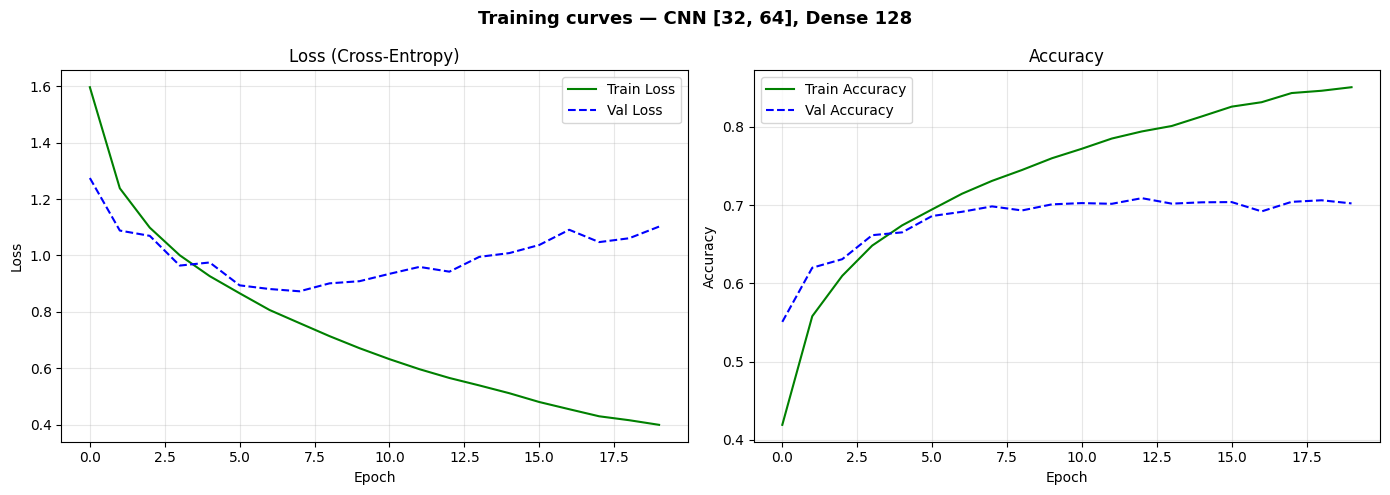

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss',  color='green')
axes[0].plot(history.history['val_loss'], label='Val Loss',    color='blue',  linestyle='--')
axes[0].set_title('Loss (Cross-Entropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='green')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='blue',  linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Training curves — CNN {CONV_FILTERS}, Dense {DENSE_UNITS}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Evaluation on the Test Set

The **test set** is used only once, at the very end, to estimate the model's real-world performance on unseen data.  
**Do not** change hyperparameters based on test-set results — that would constitute *data leakage*.

In [8]:
# ─── FIXED — do not modify this cell ──────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\n" + "═" * 55)
print(f"  Test Accuracy  : {test_acc  * 100:.2f} %")
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Total params   : {model.count_params():,}")
print("═" * 55)


═══════════════════════════════════════════════════════
  Test Accuracy  : 69.84 %
  Test Loss      : 1.1071
  Total params   : 545,098
═══════════════════════════════════════════════════════


## 9. Confusion Matrix

The **Confusion Matrix** shows, for each true class, how many samples were classified into each predicted class.  
Off-diagonal entries are misclassifications. Classes that are frequently confused with each other reveal the inherent difficulty of the task (e.g., cat vs. dog).

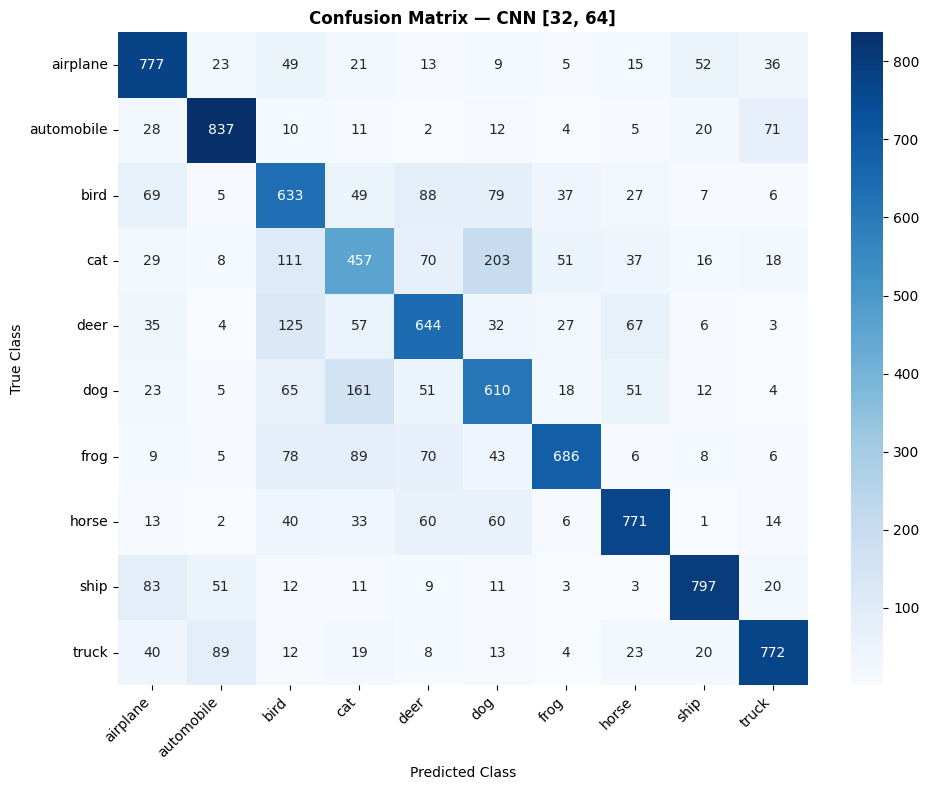


Per-class accuracy:
  airplane    :  77.7 %
  automobile  :  83.7 %
  bird        :  63.3 %
  cat         :  45.7 %
  deer        :  64.4 %
  dog         :  61.0 %
  frog        :  68.6 %
  horse       :  77.1 %
  ship        :  79.7 %
  truck       :  77.2 %


In [9]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix — CNN {CONV_FILTERS}', fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, cls in enumerate(CLASS_NAMES):
    cls_acc = cm[i, i] / cm[i].sum() * 100
    print(f"  {cls:<12}: {cls_acc:5.1f} %")

## 10. Experiment: Architecture Comparison

In this section we train **three pre-defined architectures** and compare their:
- Test accuracy
- Total number of parameters
- Estimated Flash memory footprint

This illustrates the fundamental **accuracy vs. model size trade-off** that is central to Embedded and Edge AI.

> **Question for the student:** which architecture gives the best accuracy per kilobyte of Flash memory?

In [10]:
# Architectures to compare
ARCHITECTURES = {
    'Shallow CNN\n[32]':          {'conv_filters': [32],         'dense_units': 128, 'dropout_rate': 0.3},
    'Medium CNN\n[32, 64]':       {'conv_filters': [32, 64],     'dense_units': 128, 'dropout_rate': 0.3},
    'Deep CNN\n[32, 64, 128]':    {'conv_filters': [32, 64, 128],'dense_units': 256, 'dropout_rate': 0.4},
}

COMPARISON_EPOCHS = 15   # use fewer epochs for the comparison to save time
results = []

for arch_name, cfg in ARCHITECTURES.items():
    print(f"\n{'─'*55}")
    print(f"Training: {arch_name.replace(chr(10), ' ')}")
    print(f"{'─'*55}")

    m = build_cnn(**cfg)
    m.fit(x_train, y_train,
          epochs=COMPARISON_EPOCHS,
          batch_size=64,
          validation_data=(x_val, y_val),
          verbose=0)

    _, acc   = m.evaluate(x_test, y_test, verbose=0)
    n_params = m.count_params()
    flash_kb = n_params * 4 / 1024

    results.append({
        'name':     arch_name,
        'accuracy': acc * 100,
        'params':   n_params,
        'flash_kb': flash_kb,
    })
    print(f"  Accuracy : {acc*100:.2f}%  |  Params: {n_params:,}  |  Flash: {flash_kb:.1f} KB")


───────────────────────────────────────────────────────
Training: Shallow CNN [32]
───────────────────────────────────────────────────────
  Accuracy : 62.53%  |  Params: 1,050,890  |  Flash: 4105.0 KB

───────────────────────────────────────────────────────
Training: Medium CNN [32, 64]
───────────────────────────────────────────────────────
  Accuracy : 69.06%  |  Params: 545,098  |  Flash: 2129.3 KB

───────────────────────────────────────────────────────
Training: Deep CNN [32, 64, 128]
───────────────────────────────────────────────────────
  Accuracy : 72.21%  |  Params: 620,362  |  Flash: 2423.3 KB


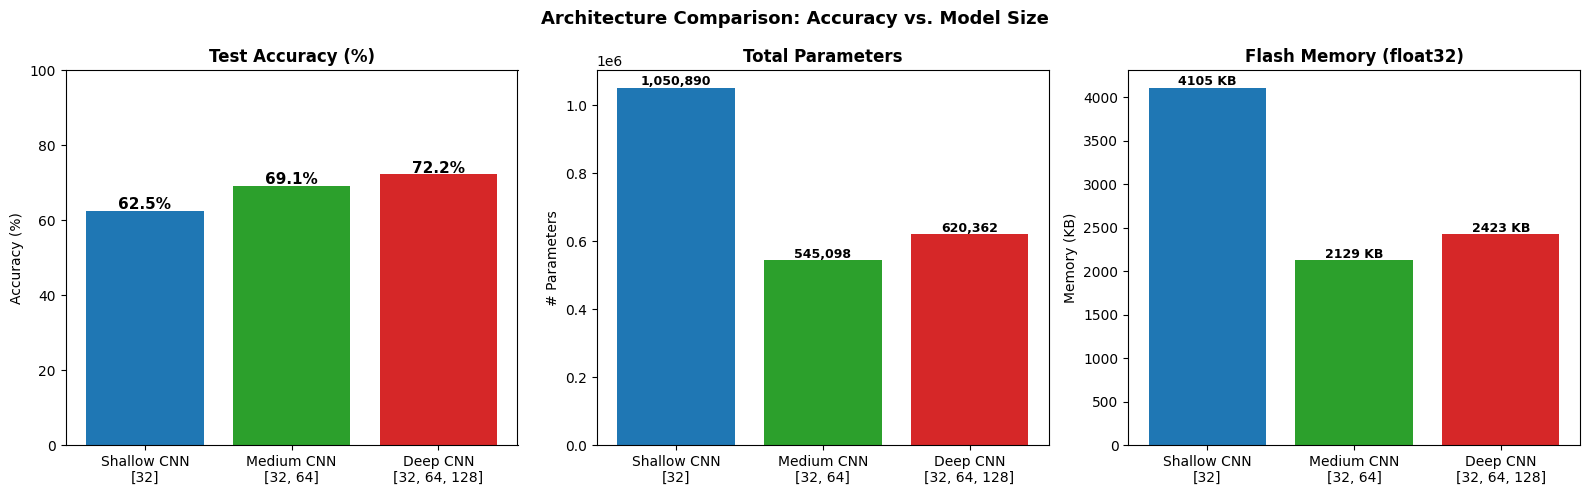


Efficiency — Accuracy per KB of Flash memory:
  Shallow CNN [32]              : 0.015 %/KB
  Medium CNN [32, 64]           : 0.032 %/KB
  Deep CNN [32, 64, 128]        : 0.030 %/KB


In [11]:
# ── Comparison charts ─────────────────────────────────────────────────────
names     = [r['name']     for r in results]
accs      = [r['accuracy'] for r in results]
params    = [r['params']   for r in results]
flash_kbs = [r['flash_kb'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bar = ['#1f77b4', '#2ca02c', '#d62728']

# Test Accuracy
axes[0].bar(names, accs, color=colors_bar)
axes[0].set_title('Test Accuracy (%)', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Total Parameters
axes[1].bar(names, params, color=colors_bar)
axes[1].set_title('Total Parameters', fontweight='bold')
axes[1].set_ylabel('# Parameters')
for i, v in enumerate(params):
    axes[1].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Flash Memory
axes[2].bar(names, flash_kbs, color=colors_bar)
axes[2].set_title('Flash Memory (float32)', fontweight='bold')
axes[2].set_ylabel('Memory (KB)')
for i, v in enumerate(flash_kbs):
    axes[2].text(i, v * 1.01, f'{v:.0f} KB', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Architecture Comparison: Accuracy vs. Model Size',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Accuracy-per-kilobyte (efficiency metric) ────────────────────────────
print("\nEfficiency — Accuracy per KB of Flash memory:")
for r in results:
    eff = r['accuracy'] / r['flash_kb']
    print(f"  {r['name'].replace(chr(10),' '):<30}: {eff:.3f} %/KB")

## 11. Summary and Discussion

Complete the following table with the values obtained from your experiments:

| Architecture | # Conv blocks | Filters | Total params | Flash (KB) | Test accuracy (%) |
|:---|:---:|:---:|---:|---:|---:|
| Your config 1 | | | | | |
| Your config 2 | | | | | |
| Your config 3 | | | | | |

**Discussion questions:**

1. How does adding a convolutional block affect the number of parameters? Is the relationship linear or non-linear? Why?
2. Is the model with the most parameters always the most accurate? What phenomenon might prevent this?
4. On a microcontroller with 256 KB of Flash, which of the architectures you tested could be deployed **without** quantisation (considering only the weights)?